In [1]:
!pip install -r ../requirements.txt


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import re
import math
import random
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
np.random.seed(42)
random.seed(42)

In [3]:
# Spark session
from pyspark.sql import SparkSession
from pyspark.sql.types import (
    StructType, StructField, IntegerType, FloatType, LongType, StringType
)
from pyspark.sql import functions as F
from pyspark.storagelevel import StorageLevel

spark = SparkSession.builder \
    .appName("Assignment03_MovieLens_Recommender") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.executor.memory", "4g") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/03/15 09:02:21 WARN Utils: Your hostname, ASHISHs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 192.168.1.5 instead (on interface en0)
26/03/15 09:02:21 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/15 09:02:21 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.1


In [4]:
# Dataset paths
project_root = Path.cwd().resolve().parent
data_dir = project_root / "dataset" / "ml-latest-small"

ratings_file = (data_dir / "ratings.csv").resolve()
movies_file = (data_dir / "movies.csv").resolve()
tags_file = (data_dir / "tags.csv").resolve()

assert ratings_file.exists(), f"ratings.csv not found: {ratings_file}"
assert movies_file.exists(), f"movies.csv not found: {movies_file}"

ratings_path = f"file://{ratings_file}"
movies_path = f"file://{movies_file}"
tags_path = f"file://{tags_file}" if tags_file.exists() else None

print("Ratings path:", ratings_path)
print("Movies path :", movies_path)

Ratings path: file:///Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/dataset/ml-latest-small/ratings.csv
Movies path : file:///Users/ashishsinha/Documents/Study/MTech/Sm02/MLwDE/Assignment03/gihubrepo/iitj_m25de1047_mlbd_Assignment03/dataset/ml-latest-small/movies.csv


In [5]:
# Explicit schemas and load data
ratings_schema = StructType([
    StructField("userId", IntegerType(), True),
    StructField("movieId", IntegerType(), True),
    StructField("rating", FloatType(), True),
    StructField("timestamp", LongType(), True)
])

movies_schema = StructType([
    StructField("movieId", IntegerType(), True),
    StructField("title", StringType(), True),
    StructField("genres", StringType(), True)
])

ratings = spark.read.csv(ratings_path, header=True, schema=ratings_schema)
movies = spark.read.csv(movies_path, header=True, schema=movies_schema)

ratings = ratings.persist(StorageLevel.MEMORY_AND_DISK)
movies = movies.persist(StorageLevel.MEMORY_AND_DISK)

print("Ratings count:", ratings.count())
print("Movies count :", movies.count())

ratings.show(5, truncate=False)
movies.show(5, truncate=False)
ratings.printSchema()
movies.printSchema()

Ratings count: 100836
Movies count : 9742
+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
+------+-------+------+---------+
only showing top 5 rows
+-------+----------------------------------+-------------------------------------------+
|movieId|title                             |genres                                     |
+-------+----------------------------------+-------------------------------------------+
|1      |Toy Story (1995)                  |Adventure|Animation|Children|Comedy|Fantasy|
|2      |Jumanji (1995)                    |Adventure|Children|Fantasy                 |
|3      |Grumpier Old Men (1995)           |Comedy|Romance                             |
|4      |Waiting to Exhale (1995)          |Comedy|Drama|Romance                       |
|5   

In [6]:
# Preprocessing
movies = movies.withColumn(
    "genres_clean",
    F.when(
        F.col("genres").isNull() | (F.col("genres") == "(no genres listed)"),
        F.lit("Unknown")
    ).otherwise(F.col("genres"))
)

year_str = F.regexp_extract(F.col("title"), r"\((\d{4})\)", 1)

movies = movies.withColumn(
    "year",
    F.when(year_str != "", year_str.cast("int")).otherwise(F.lit(None).cast("int"))
)

movie_stats = ratings.groupBy("movieId").agg(
    F.avg("rating").alias("movie_avg_rating"),
    F.count("*").alias("movie_rating_count")
)

user_stats = ratings.groupBy("userId").agg(
    F.avg("rating").alias("user_avg_rating"),
    F.count("*").alias("user_rating_count")
)

ratings_enriched = ratings.join(movie_stats, "movieId", "left").join(user_stats, "userId", "left")
ratings_enriched.show(5, truncate=False)

+------+-------+------+---------+------------------+------------------+-----------------+-----------------+
|userId|movieId|rating|timestamp|movie_avg_rating  |movie_rating_count|user_avg_rating  |user_rating_count|
+------+-------+------+---------+------------------+------------------+-----------------+-----------------+
|1     |1      |4.0   |964982703|3.9209302325581397|215               |4.366379310344827|232              |
|1     |3      |4.0   |964981247|3.2596153846153846|52                |4.366379310344827|232              |
|1     |6      |4.0   |964982224|3.946078431372549 |102               |4.366379310344827|232              |
|1     |47     |5.0   |964983815|3.9753694581280787|203               |4.366379310344827|232              |
|1     |50     |5.0   |964982931|4.237745098039215 |204               |4.366379310344827|232              |
+------+-------+------+---------+------------------+------------------+-----------------+-----------------+
only showing top 5 rows


In [7]:
# Train-test split
split_ts = ratings.approxQuantile("timestamp", [0.8], 0.01)[0]

train_ratings = ratings.filter(F.col("timestamp") <= split_ts).persist(StorageLevel.MEMORY_AND_DISK)
test_ratings = ratings.filter(F.col("timestamp") > split_ts).persist(StorageLevel.MEMORY_AND_DISK)

print("Train ratings:", train_ratings.count())
print("Test ratings :", test_ratings.count())

Train ratings: 80086
Test ratings : 20750


In [8]:
# Helper fucntions
from sklearn.metrics import mean_squared_error
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse.linalg import svds

TOP_K = 5
POSITIVE_THRESHOLD = 4.0

def rmse_score(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def clip_ratings(arr, low=0.5, high=5.0):
    return np.clip(arr, low, high)

def precision_recall_at_k(pred_df, truth_df, k=5, positive_threshold=4.0):
    truth_pos = truth_df[truth_df["rating"] >= positive_threshold].groupby("userId")["movieId"].apply(set).to_dict()

    pred_topk = (
        pred_df.sort_values(["userId", "score"], ascending=[True, False])
               .groupby("userId")
               .head(k)
               .groupby("userId")["movieId"]
               .apply(list)
               .to_dict()
    )

    precisions, recalls = [], []
    for user, recs in pred_topk.items():
        truth = truth_pos.get(user, set())
        if not truth:
            continue
        hits = len(set(recs) & truth)
        precisions.append(hits / k)
        recalls.append(hits / len(truth))
    return float(np.mean(precisions)) if precisions else 0.0, float(np.mean(recalls)) if recalls else 0.0

# Part 1 — Content-Based Filtering

## Task 1:

In [9]:
# TF-IDF on genres
movies_pd = movies.select("movieId", "title", "genres_clean", "year").toPandas().copy()
movies_pd["genres_clean"] = movies_pd["genres_clean"].fillna("Unknown")

tfidf = TfidfVectorizer(token_pattern=r"[^|]+")
tfidf_matrix = tfidf.fit_transform(movies_pd["genres_clean"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (9742, 20)


In [10]:
# recommendation function
title_to_idx = pd.Series(movies_pd.index, index=movies_pd["title"]).drop_duplicates()

def recommend_similar_movies(movie_title, top_n=5):
    if movie_title not in title_to_idx:
        return pd.DataFrame(columns=["movieId", "title", "genres_clean", "year", "similarity"])

    idx = title_to_idx[movie_title]
    sims = cosine_similarity(tfidf_matrix[idx], tfidf_matrix).flatten()
    similar_idx = np.argsort(-sims)
    similar_idx = [i for i in similar_idx if i != idx][:top_n]

    result = movies_pd.iloc[similar_idx][["movieId", "title", "genres_clean", "year"]].copy()
    result["similarity"] = sims[similar_idx]
    return result.reset_index(drop=True)

for title in ["Toy Story (1995)", "Jumanji (1995)", "Matrix, The (1999)"]:
    print(f"\nRecommendations for: {title}")
    display(recommend_similar_movies(title, 5))


Recommendations for: Toy Story (1995)


,movieId,title,genres_clean,year,similarity
0,45074,"Wild, The (2006)",Adventure|Animation|Children|Comedy|Fantasy,2006.0,1.0
1,3114,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,1999.0,1.0
2,103755,Turbo (2013),Adventure|Animation|Children|Comedy|Fantasy,2013.0,1.0
3,166461,Moana (2016),Adventure|Animation|Children|Comedy|Fantasy,2016.0,1.0
4,65577,"Tale of Despereaux, The (2008)",Adventure|Animation|Children|Comedy|Fantasy,2008.0,1.0



Recommendations for: Jumanji (1995)


,movieId,title,genres_clean,year,similarity
0,126,"NeverEnding Story III, The (1994)",Adventure|Children|Fantasy,1994.0,1.0
1,119655,Seventh Son (2014),Adventure|Children|Fantasy,2014.0,1.0
2,4896,Harry Potter and the Sorcerer's Stone (a.k.a. ...,Adventure|Children|Fantasy,2001.0,1.0
3,80748,Alice in Wonderland (1933),Adventure|Children|Fantasy,1933.0,1.0
4,82169,Chronicles of Narnia: The Voyage of the Dawn T...,Adventure|Children|Fantasy,2010.0,1.0



Recommendations for: Matrix, The (1999)


,movieId,title,genres_clean,year,similarity
0,379,Timecop (1994),Action|Sci-Fi|Thriller,1994.0,1.0
1,71254,Gamer (2009),Action|Sci-Fi|Thriller,2009.0,1.0
2,3981,Red Planet (2000),Action|Sci-Fi|Thriller,2000.0,1.0
3,140956,Ready Player One,Action|Sci-Fi|Thriller,NaN,1.0
4,4443,Outland (1981),Action|Sci-Fi|Thriller,1981.0,1.0


## Task 2

In [11]:
# user-profile content recommender
train_pd = train_ratings.select("userId", "movieId", "rating").toPandas()
movieid_to_idx = pd.Series(movies_pd.index, index=movies_pd["movieId"]).drop_duplicates()

train_pd = train_pd[train_pd["movieId"].isin(movieid_to_idx.index)].copy()
train_pd["movie_idx"] = train_pd["movieId"].map(movieid_to_idx)

def build_user_profile(user_id):
    user_hist = train_pd[train_pd["userId"] == user_id]
    if user_hist.empty:
        return None

    idxs = user_hist["movie_idx"].values
    weights = user_hist["rating"].values.reshape(-1, 1)
    movie_vecs = tfidf_matrix[idxs].toarray()
    profile = (movie_vecs * weights).sum(axis=0) / weights.sum()
    return profile

def recommend_for_user_content(user_id, top_n=5):
    profile = build_user_profile(user_id)
    if profile is None:
        return pd.DataFrame(columns=["movieId", "title", "genres_clean", "score"])

    seen_movies = set(train_pd.loc[train_pd["userId"] == user_id, "movieId"])
    scores = cosine_similarity(profile.reshape(1, -1), tfidf_matrix).flatten()

    candidates = movies_pd.copy()
    candidates["score"] = scores
    candidates = candidates[~candidates["movieId"].isin(seen_movies)]
    return candidates.sort_values("score", ascending=False).head(top_n)[["movieId", "title", "genres_clean", "score"]]

active_users = train_pd.groupby("userId").size().reset_index(name="cnt")
sample_users = active_users[active_users["cnt"] >= 20]["userId"].head(3).tolist()

for uid in sample_users:
    print(f"\nUser-profile content recommendations for user {uid}")
    display(recommend_for_user_content(uid, 5))


User-profile content recommendations for user 1


,movieId,title,genres_clean,score
8597,117646,Dragonheart 2: A New Beginning (2000),Action|Adventure|Comedy|Drama|Fantasy|Thriller,0.803160
6570,55116,"Hunting Party, The (2007)",Action|Adventure|Comedy|Drama|Thriller,0.789474
4005,5657,Flashback (1990),Action|Adventure|Comedy|Crime|Drama,0.786155
4681,6990,The Great Train Robbery (1978),Action|Adventure|Comedy|Crime|Drama,0.786155
9394,164226,Maximum Ride (2016),Action|Adventure|Comedy|Fantasy|Sci-Fi|Thriller,0.775360



User-profile content recommendations for user 2


,movieId,title,genres_clean,score
118,145,Bad Boys (1995),Action|Comedy|Crime|Drama|Thriller,0.880794
1103,1432,Metro (1997),Action|Comedy|Crime|Drama|Thriller,0.880794
19,20,Money Train (1995),Action|Comedy|Crime|Drama|Thriller,0.880794
4693,7007,"Last Boy Scout, The (1991)",Action|Comedy|Crime|Drama|Thriller,0.880794
3989,5628,Wasabi (2001),Action|Comedy|Crime|Drama|Thriller,0.880794



User-profile content recommendations for user 3


,movieId,title,genres_clean,score
6789,60471,Rogue (2007),Action|Adventure|Horror|Sci-Fi|Thriller,0.926847
902,1200,Aliens (1986),Action|Adventure|Horror|Sci-Fi,0.910638
9361,161918,Sharknado 4: The 4th Awakens (2016),Action|Adventure|Horror|Sci-Fi,0.910638
6024,38583,"Wraith, The (1986)",Action|Horror|Sci-Fi|Thriller,0.897908
1009,1320,Alien³ (a.k.a. Alien 3) (1992),Action|Horror|Sci-Fi|Thriller,0.897908


In [12]:
# evaluate content recommender
test_pd = test_ratings.select("userId", "movieId", "rating").toPandas()

pred_rows = []
eval_users = sample_users[:]

for uid in eval_users:
    recs = recommend_for_user_content(uid, top_n=50)
    recs["userId"] = uid
    pred_rows.append(recs[["userId", "movieId", "score"]])

content_pred_df = pd.concat(pred_rows, ignore_index=True) if pred_rows else pd.DataFrame(columns=["userId", "movieId", "score"])
content_truth_df = test_pd[test_pd["userId"].isin(eval_users)].copy()

content_p5, content_r5 = precision_recall_at_k(content_pred_df, content_truth_df, k=5, positive_threshold=POSITIVE_THRESHOLD)
print("Content Precision@5:", round(content_p5, 4))
print("Content Recall@5   :", round(content_r5, 4))

Content Precision@5: 0.0
Content Recall@5   : 0.0


# Part 2 — Collaborative Filtering

In [13]:
# Filter active users and popular movies for fast CF
user_counts = train_ratings.groupBy("userId").count().filter(F.col("count") >= 30)
movie_counts = train_ratings.groupBy("movieId").count().filter(F.col("count") >= 50)

cf_train = train_ratings.join(user_counts.select("userId"), "userId") \
                        .join(movie_counts.select("movieId"), "movieId") \
                        .persist(StorageLevel.MEMORY_AND_DISK)

cf_pd = cf_train.select("userId", "movieId", "rating").toPandas()

user_item = cf_pd.pivot_table(index="userId", columns="movieId", values="rating")
user_item_filled = user_item.fillna(0)

print("User-item matrix shape:", user_item_filled.shape)

User-item matrix shape: (419, 339)


## Task 3

In [14]:
# User-based CF
user_similarity = cosine_similarity(user_item_filled.values)
user_similarity_df = pd.DataFrame(user_similarity, index=user_item_filled.index, columns=user_item_filled.index)

def predict_user_cf(user_id, movie_id, k=20):
    if user_id not in user_item_filled.index or movie_id not in user_item_filled.columns:
        return np.nan

    sims = user_similarity_df.loc[user_id].drop(user_id, errors="ignore")
    movie_ratings = user_item[movie_id].dropna()

    common_users = sims.index.intersection(movie_ratings.index)
    if len(common_users) == 0:
        return np.nan

    sims = sims.loc[common_users]
    movie_ratings = movie_ratings.loc[common_users]

    top_neighbors = sims.sort_values(ascending=False).head(k)
    neighbor_ratings = movie_ratings.loc[top_neighbors.index]

    denom = np.abs(top_neighbors).sum()
    if denom == 0:
        return np.nan

    return float((top_neighbors * neighbor_ratings).sum() / denom)

def recommend_user_cf(user_id, k=20, top_n=5):
    seen = set(cf_pd.loc[cf_pd["userId"] == user_id, "movieId"])
    candidates = [m for m in user_item_filled.columns if m not in seen]

    preds = []
    for m in candidates[:5000]:
        pred = predict_user_cf(user_id, m, k=k)
        if not np.isnan(pred):
            preds.append((m, pred))

    recs = pd.DataFrame(preds, columns=["movieId", "pred_rating"]).sort_values("pred_rating", ascending=False).head(top_n)
    return recs.merge(movies_pd[["movieId", "title", "genres_clean"]], on="movieId", how="left")

sample_user_cf = int(user_item_filled.index[0])
display(recommend_user_cf(sample_user_cf, k=20, top_n=5))

,movieId,pred_rating,title,genres_clean
0,858,4.704211,"Godfather, The (1972)",Crime|Drama
1,79132,4.543550,Inception (2010),Action|Crime|Drama|Mystery|Sci-Fi|Thriller|IMAX
2,750,4.540471,Dr. Strangelove or: How I Learned to Stop Worr...,Comedy|War
3,1221,4.530122,"Godfather: Part II, The (1974)",Crime|Drama
4,912,4.471188,Casablanca (1942),Drama|Romance


In [15]:
# evaluate user-based CF
cf_test_pd = test_ratings.select("userId", "movieId", "rating").toPandas()
cf_test_pd = cf_test_pd[
    cf_test_pd["userId"].isin(user_item_filled.index) &
    cf_test_pd["movieId"].isin(user_item_filled.columns)
].copy()

sample_eval = cf_test_pd.sample(min(2000, len(cf_test_pd)), random_state=42)

def eval_user_cf_rmse(k=20):
    y_true, y_pred = [], []
    for row in sample_eval.itertuples(index=False):
        pred = predict_user_cf(row.userId, row.movieId, k=k)
        if not np.isnan(pred):
            y_true.append(row.rating)
            y_pred.append(pred)
    return rmse_score(y_true, clip_ratings(np.array(y_pred))) if y_true else np.nan

for k in [10, 20, 50]:
    print(f"User-CF RMSE @ k={k}: {eval_user_cf_rmse(k):.4f}")

User-CF RMSE @ k=10: 0.7335
User-CF RMSE @ k=20: 0.7136
User-CF RMSE @ k=50: 0.6984


## Task 4

In [16]:
# Item-based CF
item_user = user_item.T
item_user_filled = item_user.fillna(0)

item_similarity = cosine_similarity(item_user_filled.values)
item_similarity_df = pd.DataFrame(item_similarity, index=item_user_filled.index, columns=item_user_filled.index)

def predict_item_cf(user_id, movie_id, k=20):
    if user_id not in user_item.index or movie_id not in item_similarity_df.index:
        return np.nan

    user_rated = user_item.loc[user_id].dropna()
    if user_rated.empty:
        return np.nan

    sims = item_similarity_df.loc[movie_id, user_rated.index]
    top_items = sims.sort_values(ascending=False).head(k)
    ratings_vec = user_rated.loc[top_items.index]

    denom = np.abs(top_items).sum()
    if denom == 0:
        return np.nan

    return float((top_items * ratings_vec).sum() / denom)

def recommend_item_cf(user_id, k=20, top_n=5):
    seen = set(cf_pd.loc[cf_pd["userId"] == user_id, "movieId"])
    candidates = [m for m in item_user.index if m not in seen]

    preds = []
    for m in candidates[:5000]:
        pred = predict_item_cf(user_id, m, k=k)
        if not np.isnan(pred):
            preds.append((m, pred))

    recs = pd.DataFrame(preds, columns=["movieId", "pred_rating"]).sort_values("pred_rating", ascending=False).head(top_n)
    return recs.merge(movies_pd[["movieId", "title", "genres_clean"]], on="movieId", how="left")

display(recommend_item_cf(sample_user_cf, k=20, top_n=5))

,movieId,pred_rating,title,genres_clean
0,32587,4.852224,Sin City (2005),Action|Crime|Film-Noir|Mystery|Thriller
1,58559,4.849650,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX
2,1201,4.844523,"Good, the Bad and the Ugly, The (Buono, il bru...",Action|Adventure|Western
3,44191,4.818337,V for Vendetta (2006),Action|Sci-Fi|Thriller|IMAX
4,45722,4.814971,Pirates of the Caribbean: Dead Man's Chest (2006),Action|Adventure|Fantasy


In [17]:
# evaluate item-based CF
def eval_item_cf_rmse(k=20):
    y_true, y_pred = [], []
    for row in sample_eval.itertuples(index=False):
        pred = predict_item_cf(row.userId, row.movieId, k=k)
        if not np.isnan(pred):
            y_true.append(row.rating)
            y_pred.append(pred)
    return rmse_score(y_true, clip_ratings(np.array(y_pred))) if y_true else np.nan

for k in [10, 20, 50]:
    print(f"Item-CF RMSE @ k={k}: {eval_item_cf_rmse(k):.4f}")

Item-CF RMSE @ k=10: 0.7745
Item-CF RMSE @ k=20: 0.7769
Item-CF RMSE @ k=50: 0.7796


# Part 3 — Matrix Factorization

## Task 5

In [18]:
# Spark ALS
from pyspark.ml.recommendation import ALS
from pyspark.ml.evaluation import RegressionEvaluator

als_train, als_test = ratings.randomSplit([0.8, 0.2], seed=42)

als = ALS(
    userCol="userId",
    itemCol="movieId",
    ratingCol="rating",
    rank=20,
    maxIter=10,
    regParam=0.1,
    coldStartStrategy="drop",
    nonnegative=True
)

als_model = als.fit(als_train)
als_predictions = als_model.transform(als_test)

reg_eval = RegressionEvaluator(metricName="rmse", labelCol="rating", predictionCol="prediction")
als_rmse = reg_eval.evaluate(als_predictions)

print("ALS RMSE:", round(als_rmse, 4))
als_predictions.show(5, truncate=False)

26/03/15 09:02:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


ALS RMSE: 0.8728
+------+-------+------+----------+----------+
|userId|movieId|rating|timestamp |prediction|
+------+-------+------+----------+----------+
|12    |357    |3.5   |1247264106|4.149503  |
|12    |543    |3.5   |1247263318|3.9472995 |
|12    |830    |4.0   |1247263452|3.961275  |
|12    |2072   |5.0   |1247263670|3.79289   |
|12    |2717   |5.0   |1247263428|3.3940637 |
+------+-------+------+----------+----------+
only showing top 5 rows


In [19]:
# ALS top-5 recommendations
als_recs = als_model.recommendForAllUsers(5)
als_recs.show(3, truncate=False)

+------+------------------------------------------------------------------------------------------------------+
|userId|recommendations                                                                                       |
+------+------------------------------------------------------------------------------------------------------+
|1     |[{78836, 5.2922196}, {171495, 5.2742524}, {3508, 5.25072}, {6732, 5.22884}, {5416, 5.2234945}]        |
|2     |[{131724, 4.8963585}, {86377, 4.7080326}, {171495, 4.7020607}, {78836, 4.6852064}, {184245, 4.663294}]|
|3     |[{6835, 4.943314}, {5746, 4.943314}, {5181, 4.887709}, {4518, 4.7973595}, {2851, 4.665694}]           |
+------+------------------------------------------------------------------------------------------------------+
only showing top 3 rows


In [20]:
# ALS Precision@5 and Recall@5
als_recs_exploded = als_recs.select(
    "userId",
    F.explode("recommendations").alias("rec")
).select(
    "userId",
    F.col("rec.movieId").alias("movieId"),
    F.col("rec.rating").alias("score")
)

als_pred_pd = als_recs_exploded.toPandas()
als_test_pd = als_test.select("userId", "movieId", "rating").toPandas()

als_p5, als_r5 = precision_recall_at_k(als_pred_pd, als_test_pd, k=5, positive_threshold=POSITIVE_THRESHOLD)
print("ALS Precision@5:", round(als_p5, 4))
print("ALS Recall@5   :", round(als_r5, 4))

ALS Precision@5: 0.0037
ALS Recall@5   : 0.0018


In [21]:
# Local SVD on filtered matrix
R = user_item.fillna(0).values
user_ids_local = user_item.index.to_list()
movie_ids_local = user_item.columns.to_list()

k_latent = min(20, min(R.shape) - 1)
U, s, Vt = svds(R, k=k_latent)
sigma = np.diag(s)
R_hat = np.dot(np.dot(U, sigma), Vt)
R_hat = clip_ratings(R_hat)

R_hat_df = pd.DataFrame(R_hat, index=user_ids_local, columns=movie_ids_local)
print("Local SVD reconstructed matrix shape:", R_hat_df.shape)

Local SVD reconstructed matrix shape: (419, 339)


## Task 6

In [22]:
# Surprise SVD
try:
    from surprise import Dataset, Reader, SVD
    from surprise.model_selection import train_test_split as surprise_train_test_split
    from surprise import accuracy

    surprise_df = train_ratings.select("userId", "movieId", "rating").limit(500000).toPandas()
    reader = Reader(rating_scale=(0.5, 5.0))
    surprise_data = Dataset.load_from_df(surprise_df[["userId", "movieId", "rating"]], reader)

    trainset, testset = surprise_train_test_split(surprise_data, test_size=0.2, random_state=42)
    surprise_algo = SVD(n_factors=50, n_epochs=20, random_state=42)
    surprise_algo.fit(trainset)
    surprise_preds = surprise_algo.test(testset)

    surprise_rmse = accuracy.rmse(surprise_preds, verbose=False)
    print("Surprise SVD RMSE:", round(surprise_rmse, 4))
except Exception as e:
    print("Surprise section skipped:", e)

Surprise SVD RMSE: 0.8698


# Part 4 — Hybrid Recommendation Model

## Task 7

In [26]:
# weighted hybrid
movie_stats_pd = movie_stats.toPandas()
ALPHA = 0.5

def hybrid_recommend(user_id, top_n=5):
    cbf = recommend_for_user_content(user_id, top_n=100).copy()
    cbf = cbf.rename(columns={"score": "cbf_score"})

    itemcf = recommend_item_cf(user_id, k=20, top_n=100).copy()
    itemcf = itemcf.rename(columns={"pred_rating": "cf_score"})

    hybrid = cbf.merge(itemcf[["movieId", "cf_score"]], on="movieId", how="outer")

    hybrid = hybrid.merge(
        movie_stats_pd[["movieId", "movie_avg_rating", "movie_rating_count"]],
        on="movieId",
        how="left"
    )

    user_avg = train_pd.loc[train_pd["userId"] == user_id, "rating"].mean()
    hybrid["user_avg_rating"] = user_avg if not np.isnan(user_avg) else 3.0

    hybrid["cbf_score"] = hybrid["cbf_score"].fillna(0.0)
    hybrid["cf_score"] = hybrid["cf_score"].fillna(hybrid["movie_avg_rating"].fillna(3.0))

    # fill title/genres for rows that came only from itemcf side
    hybrid = hybrid.merge(
        movies_pd[["movieId", "title", "genres_clean"]],
        on="movieId",
        how="left",
        suffixes=("", "_meta")
    )

    if "title_meta" in hybrid.columns:
        hybrid["title"] = hybrid["title"].fillna(hybrid["title_meta"])
        hybrid.drop(columns=["title_meta"], inplace=True)

    if "genres_clean_meta" in hybrid.columns:
        hybrid["genres_clean"] = hybrid["genres_clean"].fillna(hybrid["genres_clean_meta"])
        hybrid.drop(columns=["genres_clean_meta"], inplace=True)

    hybrid["final_score"] = ALPHA * hybrid["cbf_score"] + (1 - ALPHA) * hybrid["cf_score"]

    return hybrid.sort_values("final_score", ascending=False).head(top_n)[
        ["movieId", "title", "genres_clean", "cbf_score", "cf_score", "final_score"]
    ]

display(hybrid_recommend(sample_users[0], top_n=5))

,movieId,title,genres_clean,cbf_score,cf_score,final_score
99,6016,City of God (Cidade de Deus) (2002),Action|Adventure|Crime|Drama|Thriller,0.738972,4.751447,2.745209
104,6539,Pirates of the Caribbean: The Curse of the Bla...,Action|Adventure|Comedy|Fantasy,0.719408,4.704807,2.712108
44,2683,Austin Powers: The Spy Who Shagged Me (1999),Action|Adventure|Comedy,0.713338,4.656625,2.684982
185,117646,Dragonheart 2: A New Beginning (2000),Action|Adventure|Comedy|Drama|Fantasy|Thriller,0.803160,4.500000,2.651580
92,5657,Flashback (1990),Action|Adventure|Comedy|Crime|Drama,0.786155,4.500000,2.643078


In [27]:
# simple meta-model hybrid
from sklearn.linear_model import LinearRegression

hybrid_rows = []
for uid in sample_users:
    user_test = test_pd[test_pd["userId"] == uid]
    if user_test.empty:
        continue

    cbf_df = recommend_for_user_content(uid, top_n=500)
    cbf_map = dict(zip(cbf_df["movieId"], cbf_df["score"]))

    for row in user_test.itertuples(index=False):
        cf_pred = predict_item_cf(uid, row.movieId, k=20)
        movie_info = movie_stats_pd[movie_stats_pd["movieId"] == row.movieId]
        movie_avg = float(movie_info["movie_avg_rating"].iloc[0]) if not movie_info.empty else 3.0
        movie_cnt = int(movie_info["movie_rating_count"].iloc[0]) if not movie_info.empty else 0
        user_avg = float(train_pd.loc[train_pd["userId"] == uid, "rating"].mean()) if uid in train_pd["userId"].values else 3.0

        hybrid_rows.append({
            "userId": uid,
            "movieId": row.movieId,
            "cbf_score": cbf_map.get(row.movieId, 0.0),
            "cf_score": float(cf_pred) if not np.isnan(cf_pred) else movie_avg,
            "movie_avg_rating": movie_avg,
            "movie_rating_count": movie_cnt,
            "user_avg_rating": user_avg,
            "target_rating": row.rating
        })

hybrid_train_df = pd.DataFrame(hybrid_rows)
print("Hybrid training rows:", len(hybrid_train_df))

if len(hybrid_train_df) > 0:
    X = hybrid_train_df[["cbf_score", "cf_score", "movie_avg_rating", "movie_rating_count", "user_avg_rating"]]
    y = hybrid_train_df["target_rating"]

    meta_model = LinearRegression()
    meta_model.fit(X, y)

    hybrid_train_df["meta_pred"] = clip_ratings(meta_model.predict(X))
    print("Hybrid Meta-Model RMSE:", round(rmse_score(y, hybrid_train_df["meta_pred"]), 4))

Hybrid training rows: 0


# Part 5 — Learning-Based Recommender Systems

## Task 8

In [28]:
# build user and movie features
movies_feat_pd = movies_pd.copy()
movies_feat_pd["genre_list"] = movies_feat_pd["genres_clean"].str.split("|")
all_genres = sorted(set(g for lst in movies_feat_pd["genre_list"] for g in lst if g))
genre_to_idx = {g: i for i, g in enumerate(all_genres)}

def multi_hot(genres):
    vec = np.zeros(len(all_genres), dtype=np.float32)
    for g in genres:
        if g in genre_to_idx:
            vec[genre_to_idx[g]] = 1.0
    return vec

movies_feat_pd["genre_vec"] = movies_feat_pd["genre_list"].apply(multi_hot)
movies_feat_pd = movies_feat_pd.merge(movie_stats_pd, on="movieId", how="left")
movies_feat_pd["movie_avg_rating"] = movies_feat_pd["movie_avg_rating"].fillna(3.0)
movies_feat_pd["year"] = movies_feat_pd["year"].fillna(movies_feat_pd["year"].median())

movies_feat_pd["year_norm"] = (movies_feat_pd["year"] - movies_feat_pd["year"].min()) / (movies_feat_pd["year"].max() - movies_feat_pd["year"].min() + 1e-9)
movies_feat_pd["avg_rating_norm"] = (movies_feat_pd["movie_avg_rating"] - 0.5) / (5.0 - 0.5)

movie_feature_map = {}
for row in movies_feat_pd.itertuples(index=False):
    feat = np.concatenate([row.genre_vec, np.array([row.year_norm, row.avg_rating_norm], dtype=np.float32)])
    movie_feature_map[row.movieId] = feat

train_user_movie = train_pd.merge(movies_feat_pd[["movieId", "genre_list"]], on="movieId", how="left")

user_feature_map = {}
for uid, grp in train_user_movie.groupby("userId"):
    genre_sum = np.zeros(len(all_genres), dtype=np.float32)
    genre_cnt = np.zeros(len(all_genres), dtype=np.float32)
    for _, r in grp.iterrows():
        for g in r["genre_list"]:
            idx = genre_to_idx[g]
            genre_sum[idx] += r["rating"]
            genre_cnt[idx] += 1
    genre_avg = np.divide(genre_sum, genre_cnt, out=np.zeros_like(genre_sum), where=genre_cnt > 0)
    user_avg = np.array([grp["rating"].mean() / 5.0], dtype=np.float32)
    user_feature_map[uid] = np.concatenate([genre_avg, user_avg])

print("Movie feature length:", len(next(iter(movie_feature_map.values()))))
print("User feature length :", len(next(iter(user_feature_map.values()))))

Movie feature length: 22
User feature length : 21


Epoch 1/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.7125 - mae: 0.9516 - val_loss: 0.8453 - val_mae: 0.7183
Epoch 2/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 805us/step - loss: 0.7608 - mae: 0.6751 - val_loss: 0.7133 - val_mae: 0.6490
Epoch 3/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 849us/step - loss: 0.6892 - mae: 0.6387 - val_loss: 0.6963 - val_mae: 0.6351
Epoch 4/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 803us/step - loss: 0.6751 - mae: 0.6309 - val_loss: 0.6863 - val_mae: 0.6324
Epoch 5/5
126/126 ━━━━━━━━━━━━━━━━━━━━ 0s 926us/step - loss: 0.6682 - mae: 0.6268 - val_loss: 0.6868 - val_mae: 0.6418


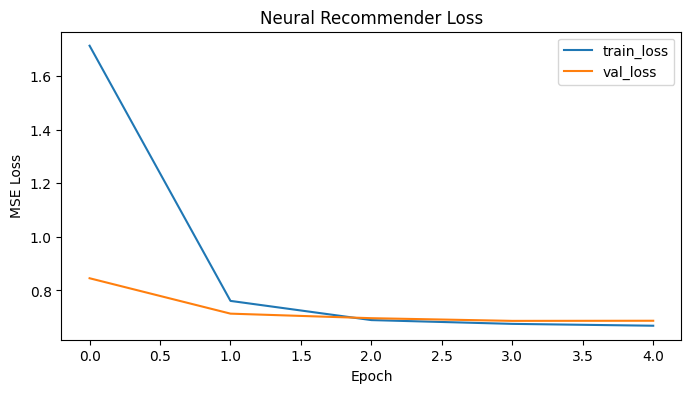

In [29]:
# neural recommender
try:
    import tensorflow as tf
    from tensorflow.keras.layers import Input, Dense, Concatenate
    from tensorflow.keras.models import Model
    from sklearn.model_selection import train_test_split

    nn_rows = []
    nn_source = train_pd[train_pd["userId"].isin(list(user_feature_map.keys())) & train_pd["movieId"].isin(list(movie_feature_map.keys()))].copy()
    nn_source = nn_source.sample(min(300000, len(nn_source)), random_state=42)

    for row in nn_source.itertuples(index=False):
        nn_rows.append((user_feature_map[row.userId], movie_feature_map[row.movieId], row.rating))

    X_user = np.stack([r[0] for r in nn_rows]).astype(np.float32)
    X_movie = np.stack([r[1] for r in nn_rows]).astype(np.float32)
    y = np.array([r[2] for r in nn_rows], dtype=np.float32)

    X_user_train, X_user_val, X_movie_train, X_movie_val, y_train, y_val = train_test_split(
        X_user, X_movie, y, test_size=0.2, random_state=42
    )

    user_input = Input(shape=(X_user.shape[1],))
    u = Dense(64, activation="relu")(user_input)
    u = Dense(32, activation="relu")(u)

    movie_input = Input(shape=(X_movie.shape[1],))
    m = Dense(64, activation="relu")(movie_input)
    m = Dense(32, activation="relu")(m)

    x = Concatenate()([u, m])
    x = Dense(64, activation="relu")(x)
    x = Dense(32, activation="relu")(x)
    output = Dense(1, activation="linear")(x)

    nn_model = Model(inputs=[user_input, movie_input], outputs=output)
    nn_model.compile(optimizer="adam", loss="mse", metrics=["mae"])

    history = nn_model.fit(
        [X_user_train, X_movie_train],
        y_train,
        validation_data=([X_user_val, X_movie_val], y_val),
        epochs=5,
        batch_size=512,
        verbose=1
    )

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="train_loss")
    plt.plot(history.history["val_loss"], label="val_loss")
    plt.title("Neural Recommender Loss")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.show()

except Exception as e:
    print("Neural recommender section skipped:", e)

## Task 9

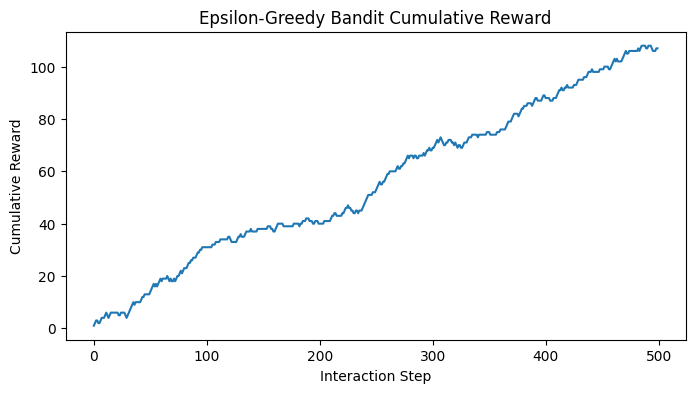

In [30]:
# Multi-Armed Bandit with epsilon-greedy
rl_pd = ratings.select("userId", "movieId", "rating").toPandas()
popular_movies = rl_pd.groupby("movieId")["rating"].count().sort_values(ascending=False).head(200).index.tolist()
rl_subset = rl_pd[rl_pd["movieId"].isin(popular_movies)].copy()

reward_table = defaultdict(dict)
for row in rl_subset.itertuples(index=False):
    reward_table[row.userId][row.movieId] = 1 if row.rating >= 4.0 else -1

class EpsilonGreedyBandit:
    def __init__(self, arms, epsilon=0.1):
        self.arms = arms
        self.epsilon = epsilon
        self.counts = {a: 0 for a in arms}
        self.values = {a: 0.0 for a in arms}

    def choose(self):
        if random.random() < self.epsilon:
            return random.choice(self.arms)
        return max(self.arms, key=lambda a: self.values[a])

    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n

bandit = EpsilonGreedyBandit(popular_movies, epsilon=0.1)

users_seq = rl_subset["userId"].drop_duplicates().sample(min(500, rl_subset["userId"].nunique()), random_state=42).tolist()
cum_rewards = []
total_reward = 0

for uid in users_seq:
    arm = bandit.choose()
    reward = reward_table.get(uid, {}).get(arm, 0)
    bandit.update(arm, reward)
    total_reward += reward
    cum_rewards.append(total_reward)

plt.figure(figsize=(8, 4))
plt.plot(cum_rewards)
plt.title("Epsilon-Greedy Bandit Cumulative Reward")
plt.xlabel("Interaction Step")
plt.ylabel("Cumulative Reward")
plt.show()

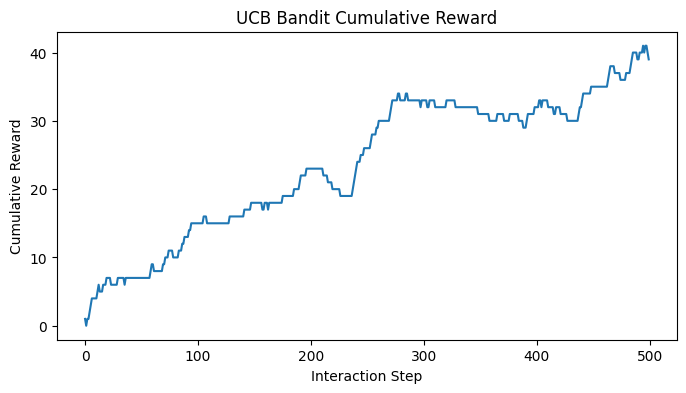

In [31]:
# UCB
class UCBBandit:
    def __init__(self, arms):
        self.arms = arms
        self.counts = {a: 0 for a in arms}
        self.values = {a: 0.0 for a in arms}
        self.total_count = 0

    def choose(self):
        self.total_count += 1
        for arm in self.arms:
            if self.counts[arm] == 0:
                return arm
        ucb_scores = {
            arm: self.values[arm] + math.sqrt(2 * math.log(self.total_count) / self.counts[arm])
            for arm in self.arms
        }
        return max(ucb_scores, key=ucb_scores.get)

    def update(self, arm, reward):
        self.counts[arm] += 1
        n = self.counts[arm]
        value = self.values[arm]
        self.values[arm] = value + (reward - value) / n

ucb = UCBBandit(popular_movies)
ucb_rewards = []
total_reward = 0

for uid in users_seq:
    arm = ucb.choose()
    reward = reward_table.get(uid, {}).get(arm, 0)
    ucb.update(arm, reward)
    total_reward += reward
    ucb_rewards.append(total_reward)

plt.figure(figsize=(8, 4))
plt.plot(ucb_rewards)
plt.title("UCB Bandit Cumulative Reward")
plt.xlabel("Interaction Step")
plt.ylabel("Cumulative Reward")
plt.show()

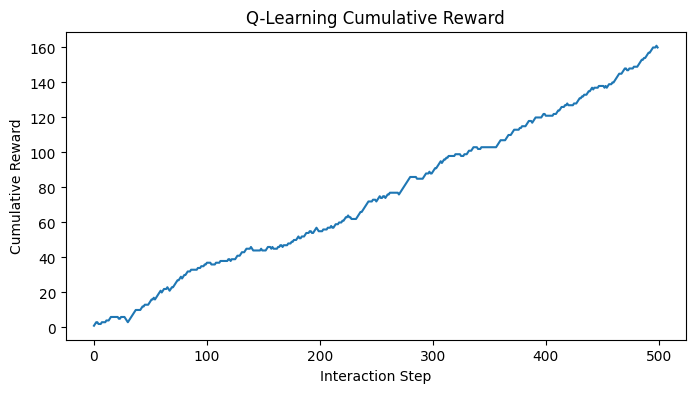

In [32]:
# simplified Q-learning
user_genre_pref = {}
for uid, grp in train_user_movie.groupby("userId"):
    genre_ratings = defaultdict(list)
    for _, row in grp.iterrows():
        for g in row["genre_list"]:
            genre_ratings[g].append(row["rating"])
    if genre_ratings:
        dominant = max(genre_ratings.items(), key=lambda x: np.mean(x[1]))[0]
        user_genre_pref[uid] = dominant

states = list(set(user_genre_pref.values()))
actions = popular_movies[:100]

Q = defaultdict(lambda: {a: 0.0 for a in actions})
alpha, gamma, epsilon = 0.1, 0.9, 0.1

def choose_action_q(state):
    if random.random() < epsilon:
        return random.choice(actions)
    return max(Q[state], key=Q[state].get)

q_rewards = []
total_reward = 0

for uid in users_seq:
    state = user_genre_pref.get(uid, random.choice(states))
    action = choose_action_q(state)
    reward = reward_table.get(uid, {}).get(action, 0)
    next_state = state
    best_next = max(Q[next_state].values())
    Q[state][action] += alpha * (reward + gamma * best_next - Q[state][action])
    total_reward += reward
    q_rewards.append(total_reward)

plt.figure(figsize=(8, 4))
plt.plot(q_rewards)
plt.title("Q-Learning Cumulative Reward")
plt.xlabel("Interaction Step")
plt.ylabel("Cumulative Reward")
plt.show()

# Part 6 — Explainability

## Task 10

In [34]:
# feature-based explanations
def explain_content_recommendation(user_id, movie_id):
    user_hist = train_pd[train_pd["userId"] == user_id].merge(
        movies_pd[["movieId", "title", "genres_clean", "year"]], on="movieId", how="left"
    )
    target = movies_pd[movies_pd["movieId"] == movie_id].iloc[0]

    liked = user_hist[user_hist["rating"] >= 4.0]
    liked_genres = "|".join(liked["genres_clean"].fillna("Unknown").tolist()).split("|")
    liked_genre_counts = pd.Series(liked_genres).value_counts()

    target_genres = target["genres_clean"].split("|")
    matched = [g for g in target_genres if g in liked_genre_counts.index]

    return {
        "userId": user_id,
        "movieId": movie_id,
        "title": target["title"],
        "matched_genres": matched,
        "reason": f"Recommended because user {user_id} frequently liked genres: {', '.join(matched[:3]) if matched else 'popular genres'}."
    }

hybrid_top = hybrid_recommend(sample_users[0], top_n=3)
feature_explanations = [explain_content_recommendation(sample_users[0], mid) for mid in hybrid_top["movieId"].tolist()]
pd.DataFrame(feature_explanations)

,userId,movieId,title,matched_genres,reason
0,1,6016,City of God (Cidade de Deus) (2002),"[Action, Adventure, Crime, Drama, Thriller]",Recommended because user 1 frequently liked ge...
1,1,6539,Pirates of the Caribbean: The Curse of the Bla...,"[Action, Adventure, Comedy, Fantasy]",Recommended because user 1 frequently liked ge...
2,1,2683,Austin Powers: The Spy Who Shagged Me (1999),"[Action, Adventure, Comedy]",Recommended because user 1 frequently liked ge...


## Task 11

In [35]:
# neighborhood-based explanations
def explain_item_cf(user_id, movie_id, k=5):
    if user_id not in user_item.index or movie_id not in item_similarity_df.index:
        return pd.DataFrame()

    user_rated = user_item.loc[user_id].dropna()
    sims = item_similarity_df.loc[movie_id, user_rated.index].sort_values(ascending=False).head(k)

    explanation = pd.DataFrame({
        "similar_movieId": sims.index,
        "similarity": sims.values,
        "user_rating": user_rated.loc[sims.index].values
    }).merge(
        movies_pd[["movieId", "title"]].rename(columns={"movieId": "similar_movieId", "title": "similar_title"}),
        on="similar_movieId",
        how="left"
    )
    return explanation

target_movie = int(hybrid_top["movieId"].iloc[0])
explain_item_cf(sample_user_cf, target_movie, k=5)

,similar_movieId,similarity,user_rating,similar_title
0,2959,0.506976,5.0,Fight Club (1999)
1,2858,0.476048,5.0,American Beauty (1999)
2,1089,0.468983,5.0,Reservoir Dogs (1992)
3,2329,0.465392,5.0,American History X (1998)
4,296,0.450043,3.0,Pulp Fiction (1994)


## Task 12

PermutationExplainer explainer: 51it [00:23,  1.34it/s]                                                                                                                                                                    


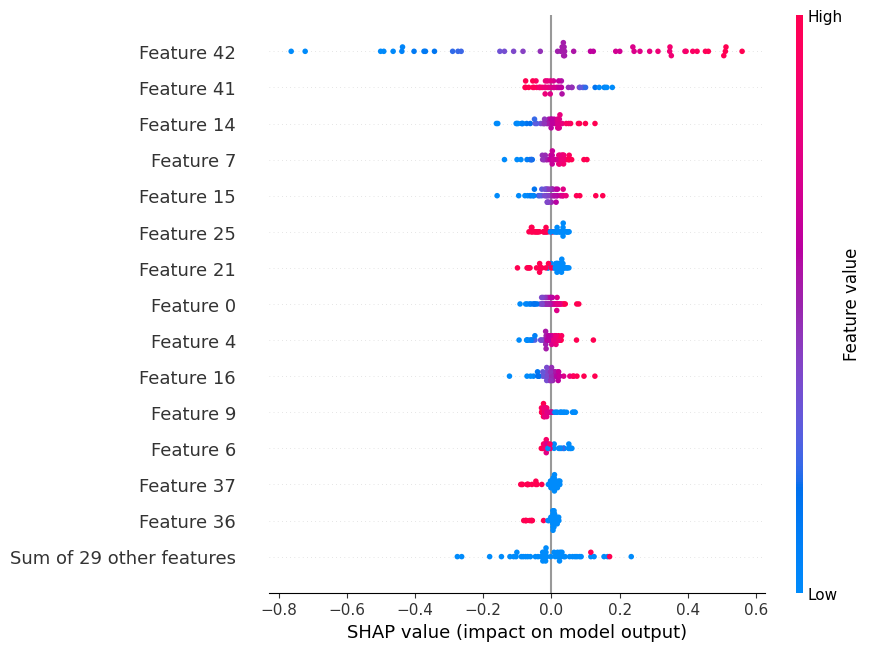

In [36]:
# SHAP explainability for the neural model
try:
    import shap

    if "nn_model" in globals():
        background_user = X_user_train[:200]
        background_movie = X_movie_train[:200]

        explainer = shap.Explainer(
            lambda data: nn_model.predict([data[:, :X_user.shape[1]], data[:, X_user.shape[1]:]], verbose=0).flatten(),
            np.hstack([background_user, background_movie])
        )

        sample_input = np.hstack([X_user_val[:50], X_movie_val[:50]])
        shap_values = explainer(sample_input)

        shap.plots.beeswarm(shap_values, max_display=15)
    else:
        print("Neural model not available; SHAP skipped.")
except Exception as e:
    print("SHAP section skipped:", e)

## Task 13

In [37]:
# explainability comparison table
explainability_summary = pd.DataFrame([
    {
        "method": "Feature-based explanation",
        "clarity": "High",
        "faithfulness": "Medium",
        "best_for": "Content-based recommender",
        "limitation": "Depends on availability of interpretable item features"
    },
    {
        "method": "Neighborhood-based explanation",
        "clarity": "High",
        "faithfulness": "High",
        "best_for": "Collaborative filtering",
        "limitation": "Needs meaningful similar users/items"
    },
    {
        "method": "SHAP/LIME explanation",
        "clarity": "Medium",
        "faithfulness": "High",
        "best_for": "Neural / black-box models",
        "limitation": "More computationally expensive and harder to explain to non-technical users"
    }
])

explainability_summary

,method,clarity,faithfulness,best_for,limitation
0,Feature-based explanation,High,Medium,Content-based recommender,Depends on availability of interpretable item ...
1,Neighborhood-based explanation,High,High,Collaborative filtering,Needs meaningful similar users/items
2,SHAP/LIME explanation,Medium,High,Neural / black-box models,More computationally expensive and harder to e...


# Final comparison

In [38]:
# Summary metrics table
results = []

results.append({
    "model": "Content User-Profile",
    "rmse": np.nan,
    "precision@5": content_p5,
    "recall@5": content_r5
})

user_cf_rmse_20 = eval_user_cf_rmse(k=20)
item_cf_rmse_20 = eval_item_cf_rmse(k=20)

results.append({
    "model": "User-CF",
    "rmse": user_cf_rmse_20,
    "precision@5": np.nan,
    "recall@5": np.nan
})

results.append({
    "model": "Item-CF",
    "rmse": item_cf_rmse_20,
    "precision@5": np.nan,
    "recall@5": np.nan
})

results.append({
    "model": "ALS",
    "rmse": als_rmse,
    "precision@5": als_p5,
    "recall@5": als_r5
})

if "hybrid_train_df" in globals() and len(hybrid_train_df) > 0:
    results.append({
        "model": "Hybrid Meta-Model",
        "rmse": rmse_score(hybrid_train_df["target_rating"], hybrid_train_df["meta_pred"]),
        "precision@5": np.nan,
        "recall@5": np.nan
    })

comparison_df = pd.DataFrame(results)
comparison_df

,model,rmse,precision@5,recall@5
0,Content User-Profile,NaN,0.000000,0.000000
1,User-CF,0.713551,NaN,NaN
2,Item-CF,0.776881,NaN,NaN
3,ALS,0.872817,0.003716,0.001803


In [40]:
# Popular fallback recommendations and closing
popular_movies_df = ratings.groupBy("movieId").agg(
    F.count("*").alias("cnt"),
    F.avg("rating").alias("avg_rating")
).filter(F.col("cnt") >= 100).orderBy(F.desc("avg_rating"), F.desc("cnt")) \
 .join(movies, "movieId") \
 .select("movieId", "title", "genres_clean", "avg_rating", "cnt") \
 .limit(10).toPandas()

print("Popular fallback recommendations:")
display(popular_movies_df)

Popular fallback recommendations:


,movieId,title,genres_clean,avg_rating,cnt
0,457,"Fugitive, The (1993)",Thriller,3.992105,190
1,1580,Men in Black (a.k.a. MIB) (1997),Action|Comedy|Sci-Fi,3.487879,165
2,1732,"Big Lebowski, The (1998)",Comedy|Crime,3.924528,106
3,2115,Indiana Jones and the Temple of Doom (1984),Action|Adventure|Fantasy,3.638889,108
4,2716,Ghostbusters (a.k.a. Ghost Busters) (1984),Action|Comedy|Sci-Fi,3.775000,120
5,6874,Kill Bill: Vol. 1 (2003),Action|Crime|Thriller,3.961832,131
6,58559,"Dark Knight, The (2008)",Action|Crime|Drama|IMAX,4.238255,149
7,912,Casablanca (1942),Drama|Romance,4.240000,100
8,161,Crimson Tide (1995),Drama|Thriller|War,3.635922,103
9,434,Cliffhanger (1993),Action|Adventure|Thriller,3.034653,101
